<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bootstrap**

Suponga que $X_1,\ldots,X_n$ son variables aleatorias independientes
con una función de distribución común $F$.

Queremos estimar $\theta(F)$ mediante el estimador

$$
g(X_1,\ldots,X_n).
$$

Entonces,

$$
ECM(F)
=
\mathbb{E}_F
\left[
\bigl(
g(X_1,\ldots,X_n)-\theta(F)
\bigr)^2
\right].
$$

Estimaremos $F$ con

$$
F_e(x)
=
\frac{\#\{\,i : X_i \le x\,\}}{n},
$$

donde $F_e(x)$ es la **distribución empírica**.



**Ejemplo**

Esta es una muestra aleatoria de 12 tiempos de entrega:

$$
35,\;42,\;38,\;40,\;45,\;37,\;39,\;41,\;44,\;36,\;43,\;40
$$

**Instrucciones**

* Use la muestra original de 12 observaciones y genere
    1000 muestras Bootstrap a partir de $F_e(x)$.

* Para cada muestra Bootstrap, calcule la media.
* Al final:
    *  Obtenga la media de las 1000 medias.
    *  Calcule la desviación estándar.
    *  Determine los percentiles $2.5\%$ y $97.5\%$ para construir un intervalo de confianza Bootstrap del $95\%$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:

# Muestra original de tiempos de entrega
muestra_original = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

In [3]:


# Tamaño de la muestra original
n = len(muestra_original)

# Número de muestras Bootstrap
B = 1000

# Para que los resultados sean reproducibles
np.random.seed(123)

# Aquí guardaremos la media de cada muestra Bootstrap
medias_bootstrap = []


In [4]:
# ==============================
# Generación de muestras Bootstrap
# ==============================

for i in range(B):

    # Generamos una muestra Bootstrap:
    # se eligen n datos de la muestra original CON reemplazo
    muestra_bootstrap = np.random.choice(
        muestra_original,  # datos de donde se toma la muestra
        size=n,            # mismo tamaño que la muestra original
        replace=True       # con reemplazo
    )

    # Calculamos la media de la muestra Bootstrap
    media = np.mean(muestra_bootstrap)

    # Guardamos esa media
    medias_bootstrap.append(media)

# Convertimos la lista a arreglo de NumPy para facilitar cálculos
medias_bootstrap = np.array(medias_bootstrap)

In [5]:

# ==============================
# Resultados finales
# ==============================

# Media de las 1000 medias Bootstrap
media_de_medias = np.mean(medias_bootstrap)

# Desviación estándar de las medias Bootstrap
desviacion_estandar = np.std(medias_bootstrap, ddof=1)

# Percentiles para intervalo de confianza Bootstrap del 95%
percentil_2_5 = np.percentile(medias_bootstrap, 2.5)
percentil_97_5 = np.percentile(medias_bootstrap, 97.5)

# Media de la muestra original
media_original = np.mean(muestra_original)


In [6]:


# ==============================
# Mostrar resultados
# ==============================

print("Media de la muestra original:", media_original)
print("Media de las 1000 medias Bootstrap:", media_de_medias)
print("Desviación estándar Bootstrap:", desviacion_estandar)
print("Percentil 2.5%:", percentil_2_5)
print("Percentil 97.5%:", percentil_97_5)

print("\nIntervalo de confianza Bootstrap del 95%:")
print(f"({percentil_2_5}, {percentil_97_5})")

Media de la muestra original: 40.0
Media de las 1000 medias Bootstrap: 40.009
Desviación estándar Bootstrap: 0.8652799408530799
Percentil 2.5%: 38.416666666666664
Percentil 97.5%: 41.666666666666664

Intervalo de confianza Bootstrap del 95%:
(38.416666666666664, 41.666666666666664)


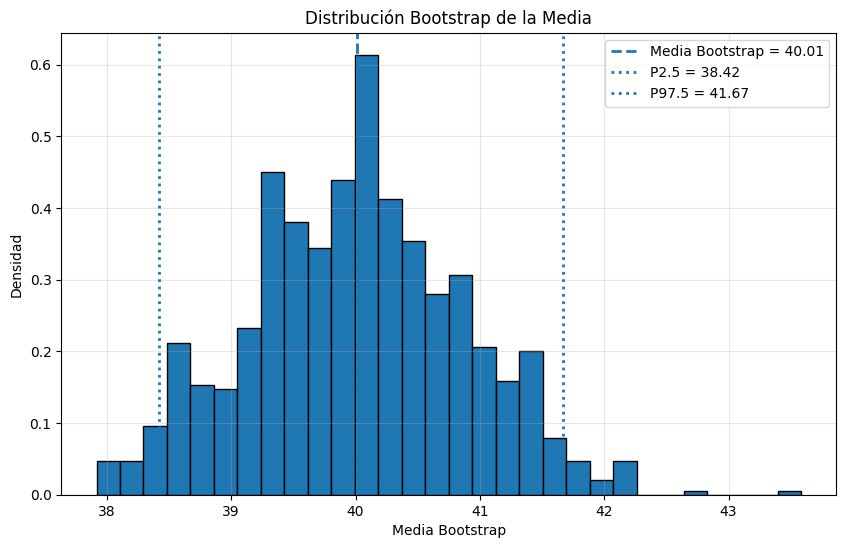

In [7]:

# Histograma de las medias Bootstrap

plt.figure(figsize=(10,6))

plt.hist(
    medias_bootstrap,
    bins=30,
    density=True,
    edgecolor='black'
)

# Media Bootstrap
plt.axvline(
    media_de_medias,
    linestyle='--',
    linewidth=2,
    label=f'Media Bootstrap = {media_de_medias:.2f}'
)

# Percentil 2.5%
plt.axvline(
    percentil_2_5,
    linestyle=':',
    linewidth=2,
    label=f'P2.5 = {percentil_2_5:.2f}'
)

# Percentil 97.5%
plt.axvline(
    percentil_97_5,
    linestyle=':',
    linewidth=2,
    label=f'P97.5 = {percentil_97_5:.2f}'
)

plt.title('Distribución Bootstrap de la Media')
plt.xlabel('Media Bootstrap')
plt.ylabel('Densidad')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

\section*{Solución Analítica}

Se tiene la muestra:

\[
35,\;42,\;38,\;40,\;45,\;37,\;39,\;41,\;44,\;36,\;43,\;40
\]

La media muestral es

\[
\bar{X}
=
\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}
=
\frac{480}{12}
=
40.
\]

En Bootstrap, la distribución empírica asigna probabilidad

\[
P(X^*=x_i)=\frac{1}{12},
\qquad i=1,\ldots,12.
\]

Por lo tanto,

\[
E(X^*)
=
\sum_{i=1}^{12}x_i\left(\frac{1}{12}\right)
=
\bar{X}
=
40.
\]

Para calcular la varianza empírica obtenemos primero

\[
\sum_{i=1}^{12}(x_i-\bar X)^2
=
(35-40)^2+(42-40)^2+\cdots+(40-40)^2.
\]

Los términos son

\[
25+4+4+0+25+9+1+1+16+16+9+0
=
110.
\]

Así,

\[
\operatorname{Var}(X^*)
=
\frac{1}{12}\sum_{i=1}^{12}(x_i-\bar X)^2
=
\frac{110}{12}
=
9.1667.
\]

Sea

\[
\bar X^*
=
\frac{1}{12}
\sum_{i=1}^{12}X_i^*
\]

la media Bootstrap. Entonces

\[
E(\bar X^*)
=
E(X^*)
=
40.
\]

Además,

\[
\operatorname{Var}(\bar X^*)
=
\frac{\operatorname{Var}(X^*)}{12}
=
\frac{9.1667}{12}
=
0.7639.
\]

La desviación estándar Bootstrap es

\[
DE(\bar X^*)
=
\sqrt{0.7639}
=
0.874.
\]

Utilizando la aproximación normal, un intervalo de confianza del
\(95\%\) para la media es

\[
\bar X
\pm
1.96\bigl(DE(\bar X^*)\bigr).
\]

Sustituyendo:

\[
40
\pm
1.96(0.874)
=
40
\pm
1.713.
\]

Por lo tanto,

\[
IC_{95\%}
=
(40-1.713,\;40+1.713)
=
(38.287,\;41.713).
\]

Finalmente,

\[
\boxed{
E(\bar X^*)=40
}
\]

\[
\boxed{
DE(\bar X^*)\approx 0.874
}
\]

\[
\boxed{
IC_{95\%}\approx(38.29,\;41.71)
}
\]